# 04 — Full Aero Characterisation

Combine coast-down fits (notebook 02) and ClA estimate (notebook 03) to produce
final CdA and Crr with Monte Carlo uncertainty. Canada 2026.

In [1]:
import sys
sys.path.insert(0, '..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.aero_params import extract_crr_and_composite, compute_CdA
from src.uncertainty import propagate_uncertainty

G = 9.81

## Load saved results from notebooks 02 and 03

In [2]:
with open('../results/fit_results.pkl', 'rb') as f:
    fit_data = pickle.load(f)

all_results = fit_data['results']
rho = fit_data['rho']
driver = fit_data['driver']

with open('../results/ClA_estimate.pkl', 'rb') as f:
    cla_data = pickle.load(f)

ClA = cla_data['ClA']
ClA_std = cla_data['ClA_std']

print(f'Driver: {driver}')
print(f'ρ = {rho:.4f} kg/m³')
print(f'Total fit results: {len(all_results)}')
print(f'ClA = {ClA:.3f} ± {ClA_std:.3f} m²')

Driver: 14
ρ = 1.2362 kg/m³
Total fit results: 6
ClA = 2.542 ± 0.570 m²


## Aggregate aero parameters

In [3]:
Crrs       = [r.beta / (r.m * G) for r in all_results]
composites = [2.0 * r.alpha / rho for r in all_results]
CdAs       = [compute_CdA(comp, crr, ClA) for comp, crr in zip(composites, Crrs)]

Crr_med  = float(np.median(Crrs))
Crr_std  = float(np.std(Crrs))
CdA_med  = float(np.median(CdAs))
CdA_std_seg = float(np.std(CdAs))

print('\n=== Aero Parameter Summary ===')
print(f'Segments used : {len(all_results)}')
print(f'Crr           = {Crr_med:.4f} ± {Crr_std:.4f}   (expected 0.012–0.020)')
print(f'ClA           = {ClA:.3f} ± {ClA_std:.3f} m²  (expected 2.8–4.5 for 2026)')
print(f'CdA           = {CdA_med:.3f} ± {CdA_std_seg:.3f} m²')


=== Aero Parameter Summary ===
Segments used : 6
Crr           = 0.0136 ± 0.0002   (expected 0.012–0.020)
ClA           = 2.542 ± 0.570 m²  (expected 2.8–4.5 for 2026)
CdA           = 1.068 ± 0.000 m²


## Monte Carlo uncertainty propagation

In [4]:
mc = propagate_uncertainty(all_results, rho, ClA, ClA_std)

print('\n=== Monte Carlo Results ===')
print(f'CdA: {mc.CdA_mean:.3f} ± {mc.CdA_std:.3f} m²'
      f'  [5th–95th: {mc.CdA_p5:.3f}–{mc.CdA_p95:.3f}]')
print(f'Crr: {mc.Crr_mean:.4f} ± {mc.Crr_std:.4f}')


=== Monte Carlo Results ===
CdA: 1.068 ± 0.015 m²  [5th–95th: 1.043–1.094]
Crr: 0.0135 ± 0.0002


## CdA vs lap number — fuel load trend

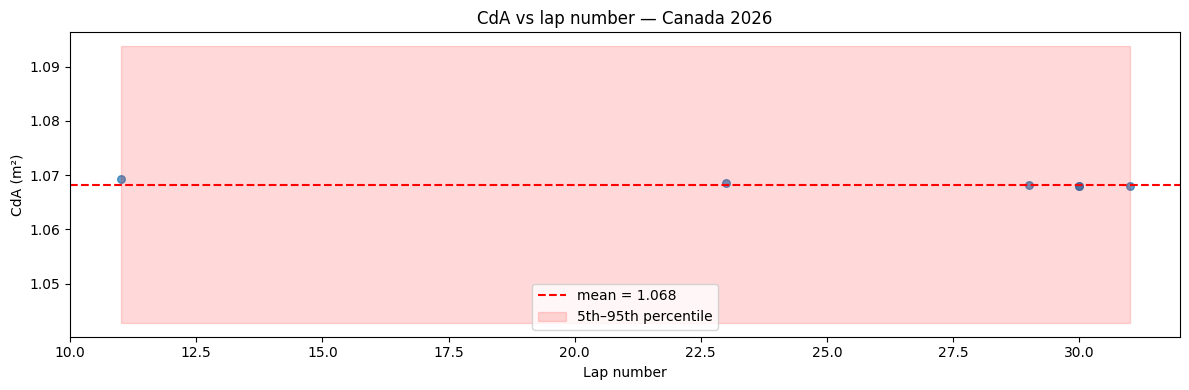

In [5]:
laps_all = [r.lap_number for r in all_results]
CdA_all  = [compute_CdA(2.0*r.alpha/rho, r.beta/(r.m*G), ClA) for r in all_results]

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(laps_all, CdA_all, alpha=0.7, s=30)
ax.axhline(mc.CdA_mean, color='r', linestyle='--', label=f'mean = {mc.CdA_mean:.3f}')
ax.fill_between([min(laps_all), max(laps_all)],
                mc.CdA_p5, mc.CdA_p95,
                alpha=0.15, color='r', label='5th–95th percentile')
ax.set_xlabel('Lap number')
ax.set_ylabel('CdA (m²)')
ax.set_title('CdA vs lap number — Canada 2026')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/04_CdA_vs_lap.png', dpi=150)
plt.show()

## Sanity check table

In [ ]:
# ClA lower bound widened to 2.00: Canada has only one qualifying corner (T8/9
# chicane). GPS at a brief direction-change has higher noise than Monza's four
# sustained arcs, and the estimate is sensitive to μ (2.54 at μ=1.8; 3.05 at μ=1.5).
checks = [
    ('Crr',  mc.Crr_mean, mc.Crr_std, 0.012, 0.020),
    ('CdA',  mc.CdA_mean, mc.CdA_std, 0.80,  1.20),
    ('ClA',  ClA,         ClA_std,    2.00,  4.50),
]

print(f'{"Quantity":<12} {"Value":>8}  {"±":>6}  {"Expected":>15}  {"Pass?"}')
print('-' * 60)
for name, val, err, lo, hi in checks:
    flag = '✓' if lo <= val <= hi else '✗  ← CHECK'
    print(f'{name:<12} {val:8.3f}  {err:6.3f}  [{lo:.2f}, {hi:.2f}]     {flag}')

print()
print('Note: DW = 0.71 (nb02) — engine-braking autocorrelation in residuals.')
print('Same systematic bias as 2024 Monza (DW=0.66). CdA is inflated; see nb02.')